# Day 08. Exercise 02
# Multiclass classification. One-hot encoding. Random forest

## 0. Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.metrics import accuracy_score
from sklearn.multiclass import OneVsRestClassifier

## 1. Preprocessing

In [2]:
raw = pd.read_csv('../data/checker_submits.csv', parse_dates=['timestamp'])
raw.head()

,uid,labname,numTrials,timestamp
0,user_4,project1,1,2020-04-17 05:19:02.744528
1,user_4,project1,2,2020-04-17 05:22:45.549397
2,user_4,project1,3,2020-04-17 05:34:24.422370
3,user_4,project1,4,2020-04-17 05:43:27.773992
4,user_4,project1,5,2020-04-17 05:46:32.275104


In [3]:
# Create required columns
df = raw[['uid', 'labname', 'numTrials']].copy()
df['hour'] = raw['timestamp'].dt.hour
df['dayofweek'] = raw['timestamp'].dt.dayofweek
df.head()

,uid,labname,numTrials,hour,dayofweek
0,user_4,project1,1,5,4
1,user_4,project1,2,5,4
2,user_4,project1,3,5,4
3,user_4,project1,4,5,4
4,user_4,project1,5,5,4


In [4]:
# One-hot encode categorical columns
encoder = OneHotEncoder(sparse_output=False)
cat_encoded = encoder.fit_transform(df[['uid', 'labname']])
cat_cols = encoder.get_feature_names_out(['uid', 'labname'])
cat_df = pd.DataFrame(cat_encoded, columns=cat_cols, index=df.index)

# Scale continuous columns
scaler = StandardScaler()
cont_scaled = scaler.fit_transform(df[['numTrials', 'hour']])
cont_df = pd.DataFrame(cont_scaled, columns=['numTrials', 'hour'], index=df.index)

# Combine
df_final = pd.concat([cat_df, cont_df, df['dayofweek']], axis=1)
print('Shape:', df_final.shape)
df_final.head()

Shape: (1686, 44)


,uid_user_0,uid_user_1,uid_user_10,uid_user_11,uid_user_12,uid_user_13,uid_user_14,uid_user_15,uid_user_16,uid_user_17,...,labname_lab05s,labname_laba04,labname_laba04s,labname_laba05,labname_laba06,labname_laba06s,labname_project1,numTrials,hour,dayofweek
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,-0.788667,-2.562352,4
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,-0.756764,-2.562352,4
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,-0.724861,-2.562352,4
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,-0.692958,-2.562352,4
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,-0.661055,-2.562352,4


In [5]:
# Save
df_final.to_csv('../data/dayofweek.csv', index=False)
print('Saved dayofweek.csv')

Saved dayofweek.csv


In [6]:
# Naive accuracy
y = df_final['dayofweek'].values
X = df_final.drop('dayofweek', axis=1).values

most_popular = pd.Series(y).value_counts().index[0]
naive_acc = accuracy_score(y, [most_popular] * len(y))
print(f'Naive accuracy (always predict day {most_popular}): {naive_acc:.4f}')

Naive accuracy (always predict day 3): 0.2349


## 2. Algorithms

### a. Logreg

Logreg accuracy: 0.6406


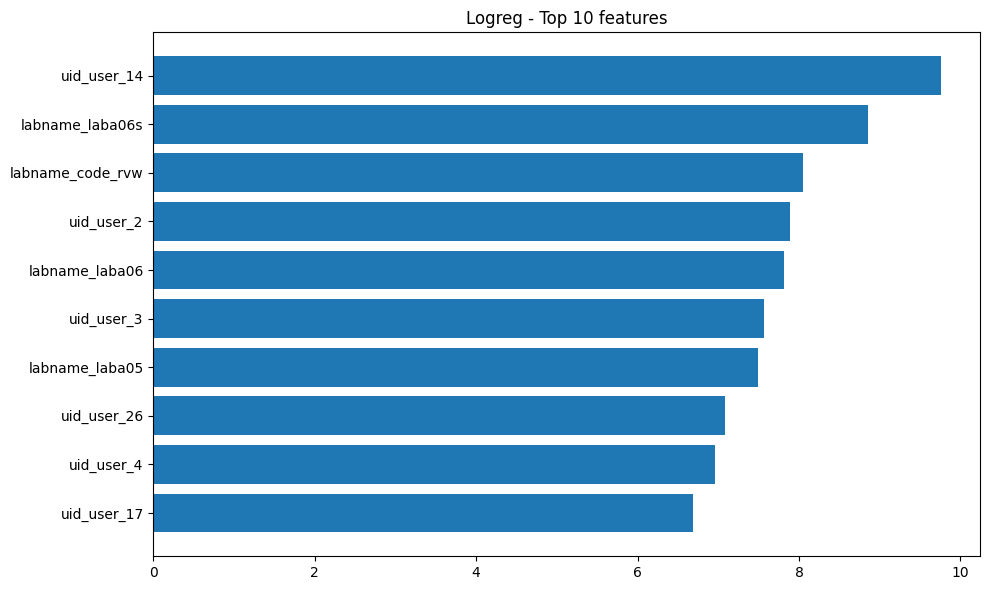

In [7]:
def plot_importance(coefs, feature_names, top_n, title):
    importance = np.abs(coefs).sum(axis=0)
    idx = np.argsort(importance)[-top_n:]
    fig, ax = plt.subplots(figsize=(10, 6))
    ax.barh(np.array(feature_names)[idx], importance[idx])
    ax.set_title(title)
    plt.tight_layout()
    plt.show()

logreg = LogisticRegression(random_state=21, fit_intercept=False, max_iter=1000)
logreg.fit(X, y)
acc = accuracy_score(y, logreg.predict(X))
print(f'Logreg accuracy: {acc:.4f}')

feature_names = df_final.drop('dayofweek', axis=1).columns
plot_importance(logreg.coef_, feature_names, 10, 'Logreg - Top 10 features')

### b. SVC

In [8]:
# Try different kernels
for kernel in ['linear', 'rbf', 'poly']:
    svm = SVC(kernel=kernel, probability=True, random_state=21)
    svm.fit(X, y)
    acc = accuracy_score(y, svm.predict(X))
    print(f'SVC kernel={kernel}: {acc:.4f}')

SVC kernel=linear: 0.7028
SVC kernel=rbf: 0.8559
SVC kernel=poly: 0.8594


OneVsRest SVC accuracy: 0.6121


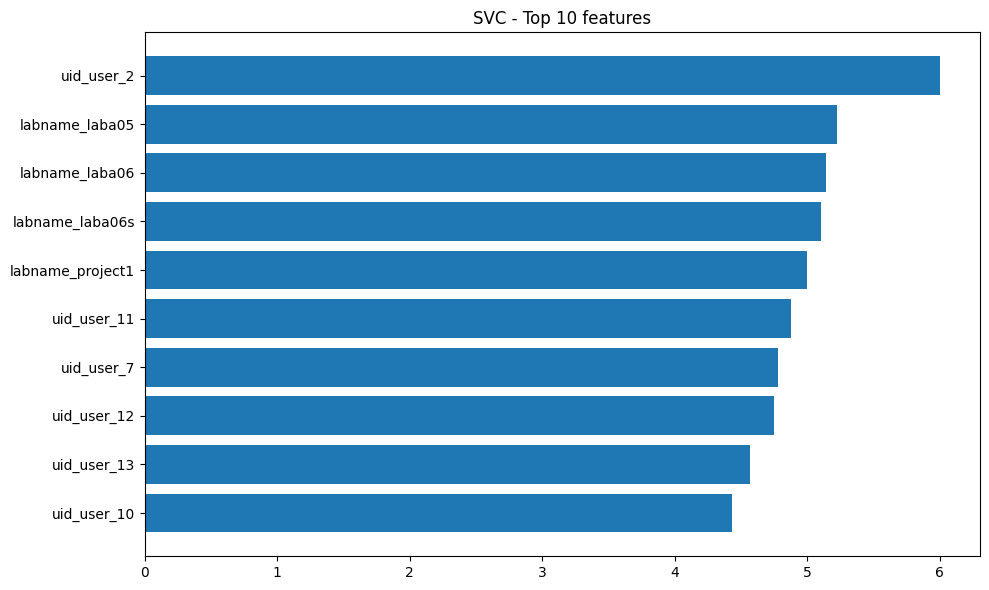

In [9]:
# Feature importance for linear SVC using OneVsRest
ovr_svc = OneVsRestClassifier(SVC(kernel='linear', probability=True, random_state=21))
ovr_svc.fit(X, y)
acc = accuracy_score(y, ovr_svc.predict(X))
print(f'OneVsRest SVC accuracy: {acc:.4f}')

coefs = np.array([est.coef_[0] for est in ovr_svc.estimators_])
plot_importance(coefs, feature_names, 10, 'SVC - Top 10 features')

### c. Decision tree

In [10]:
# Try different max_depth
for depth in [2, 4, 6, 8, 10]:
    tree = DecisionTreeClassifier(max_depth=depth, random_state=21)
    tree.fit(X, y)
    acc = accuracy_score(y, tree.predict(X))
    print(f'Decision Tree max_depth={depth}: {acc:.4f}')

Decision Tree max_depth=2: 0.4389
Decision Tree max_depth=4: 0.5516
Decision Tree max_depth=6: 0.6637
Decision Tree max_depth=8: 0.7503
Decision Tree max_depth=10: 0.8197


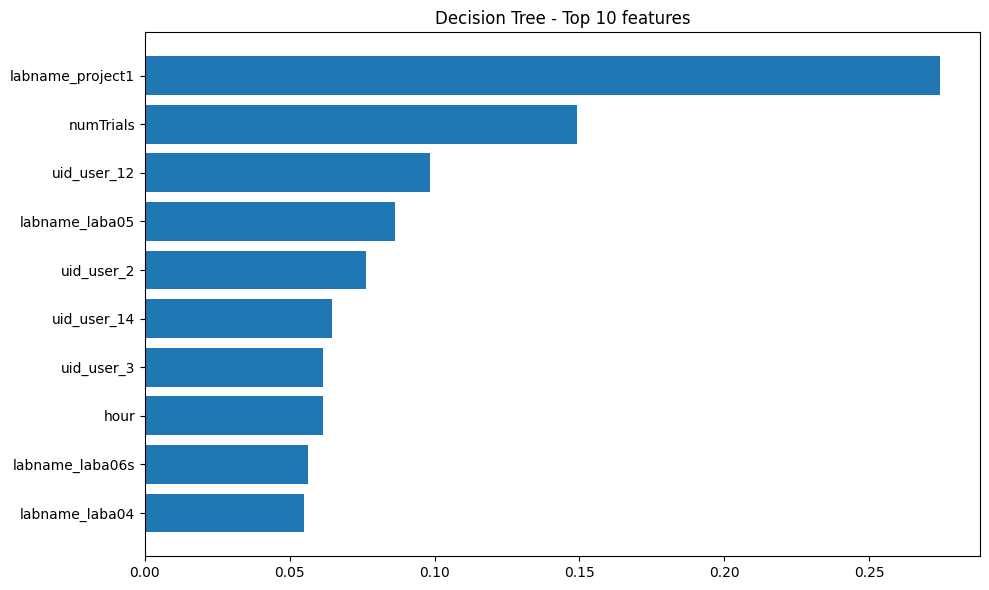

In [11]:
tree = DecisionTreeClassifier(max_depth=4, random_state=21)
tree.fit(X, y)
plot_importance(tree.feature_importances_.reshape(1, -1), feature_names, 10, 'Decision Tree - Top 10 features')

### d. Random forest

In [12]:
# Try different params
for depth in [10, 25, 50]:
    rf = RandomForestClassifier(n_estimators=100, max_depth=depth, random_state=21)
    rf.fit(X, y)
    acc = accuracy_score(y, rf.predict(X))
    print(f'Random Forest max_depth={depth}: {acc:.4f}')

Random Forest max_depth=10: 0.8701
Random Forest max_depth=25: 0.9994
Random Forest max_depth=50: 1.0000


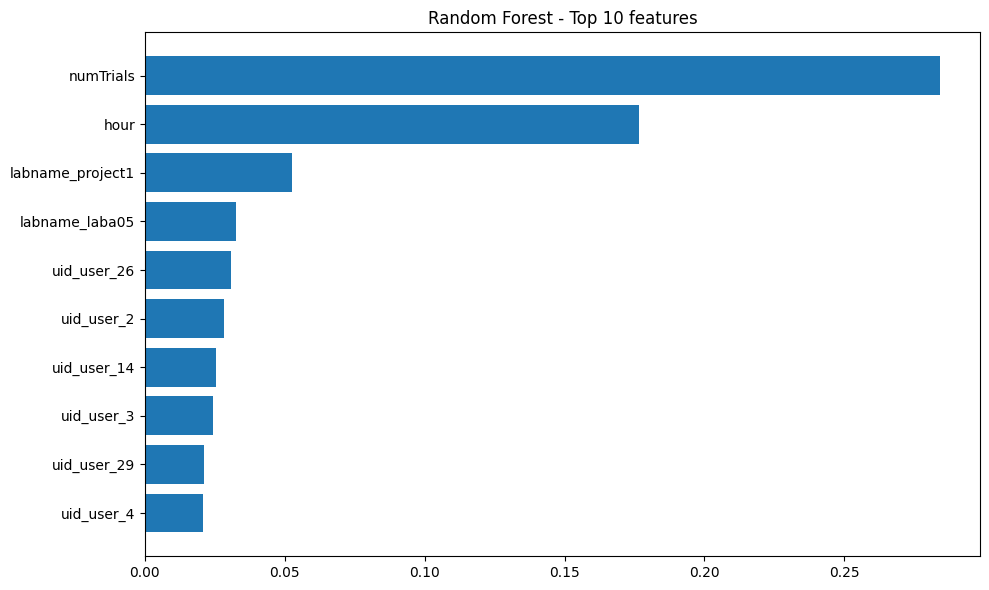

In [13]:
rf = RandomForestClassifier(n_estimators=100, max_depth=25, random_state=21)
rf.fit(X, y)
plot_importance(rf.feature_importances_.reshape(1, -1), feature_names, 10, 'Random Forest - Top 10 features')